In [1]:
import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# --- TẢI DỮ LIỆU TỰ ĐỘNG ---
# Đường dẫn tương đối từ thư mục notebooks/ trỏ ngược ra thư mục data/
data_dir = "../data"
data_path = f"{data_dir}/telco_churn.csv"
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

# Tạo thư mục data/ nếu chưa tồn tại (phòng hờ)
os.makedirs(data_dir, exist_ok=True)

# Tải file nếu chưa có
if not os.path.exists(data_path):
    print("Đang tải dữ liệu...")
    urllib.request.urlretrieve(url, data_path)
    print("✅ Đã tải và lưu vào thư mục data/")
else:
    print("✅ File dữ liệu đã tồn tại sẵn.")

# --- ĐỌC VÀ KHÁM PHÁ CƠ BẢN ---
df = pd.read_csv(data_path)

print(f"\nKích thước tập dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")
display(df.head())

print("\n--- THÔNG TIN CÁC CỘT VÀ KIỂU DỮ LIỆU ---")
df.info()

print("\n--- KIỂM TRA GIÁ TRỊ THIẾU (MISSING VALUES) ---")
print(df.isnull().sum())

Đang tải dữ liệu...
✅ Đã tải và lưu vào thư mục data/

Kích thước tập dữ liệu: 7043 dòng, 21 cột


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



--- THÔNG TIN CÁC CỘT VÀ KIỂU DỮ LIỆU ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16 

C:\Users\Home\AppData\Local\Temp\ipykernel_12420\274273793.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Churn', palette=['#43a2ca', '#e34a33'])


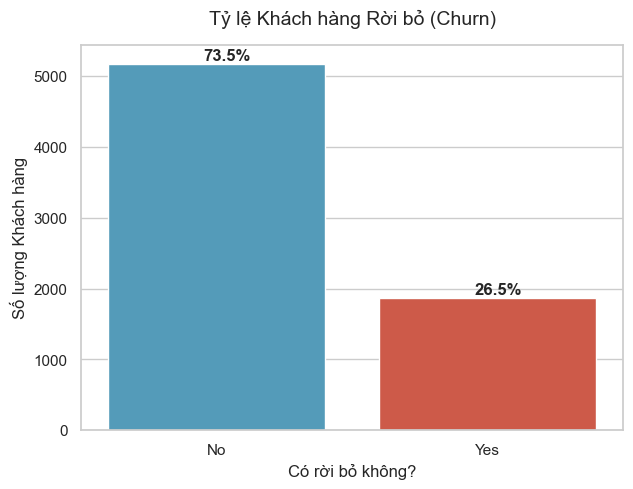

In [2]:
# --- TRỰC QUAN HÓA SỰ MẤT CÂN BẰNG DỮ LIỆU (CLASS IMBALANCE) ---
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='Churn', palette=['#43a2ca', '#e34a33'])

plt.title('Tỷ lệ Khách hàng Rời bỏ (Churn)', fontsize=14, pad=15)
plt.xlabel('Có rời bỏ không?', fontsize=12)
plt.ylabel('Số lượng Khách hàng', fontsize=12)

# Thêm số liệu phần trăm lên biểu đồ
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 50
    ax.annotate(percentage, (x, y), size=12, weight='bold')

plt.show()

In [3]:
# 1. Ép kiểu TotalCharges từ dạng chữ sang số thực (float)
# Tham số errors='coerce' cực kỳ hữu ích: Nó ép tất cả các khoảng trắng lỗi thành giá trị NaN (Not a Number)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Kiểm tra xem có bao nhiêu dòng NaN vừa được sinh ra
missing_count = df['TotalCharges'].isnull().sum()
print(f"Số lượng giá trị thiếu ở cột TotalCharges: {missing_count}")

# 2. Xóa các dòng bị thiếu
# Vì số lượng quá ít (thường là 11 dòng trên tổng số >7000 dòng), cách tốt nhất là xóa luôn để không ảnh hưởng dữ liệu.
df.dropna(subset=['TotalCharges'], inplace=True)

# 3. Xóa cột customerID vì ID không mang ý nghĩa thống kê, đưa vào mô hình sẽ gây nhiễu
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

print(f"Kích thước dữ liệu hiện tại: {df.shape}")

Số lượng giá trị thiếu ở cột TotalCharges: 11
Kích thước dữ liệu hiện tại: (7032, 20)


In [4]:
from sklearn.preprocessing import LabelEncoder

# Tách riêng biến mục tiêu (Target variable)
target_col = 'Churn'

# Tách các cột có kiểu dữ liệu là 'object' (chữ)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Xóa cột Target ra khỏi danh sách các đặc trưng (features)
if target_col in cat_cols:
    cat_cols.remove(target_col)

# --- 2.1 Mã hóa biến mục tiêu (Label Encoding) ---
# Biến 'Churn' chỉ có Yes/No, ta chuyển thành 1/0
le = LabelEncoder()
df[target_col] = le.fit_transform(df[target_col])
print("✅ Đã chuyển đổi cột Churn (Yes -> 1, No -> 0)")


# --- 2.2 Mã hóa các đặc trưng đầu vào (One-Hot Encoding) ---
# Dùng pd.get_dummies cho các cột phân loại còn lại.
# Tham số drop_first=True giúp tránh bẫy đa cộng tuyến (Dummy Variable Trap).
# Ví dụ: Giới tính thay vì tạo ra 2 cột 'Gender_Male' và 'Gender_Female', nó chỉ tạo 1 cột 'Gender_Male' (1 là nam, 0 là nữ).
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Vì pd.get_dummies tạo ra các cột kiểu boolean (True/False), ta cần ép nó về số nguyên (1/0)
df = df.astype(int)

print(f"✅ Đã One-Hot Encoding các cột phân loại.")
print(f"Kích thước dữ liệu sau khi mã hóa: {df.shape[0]} dòng, {df.shape[1]} cột")

# Xem thử 5 dòng đầu tiên sau khi biến tất cả thành số
display(df.head())

✅ Đã chuyển đổi cột Churn (Yes -> 1, No -> 0)
✅ Đã One-Hot Encoding các cột phân loại.
Kích thước dữ liệu sau khi mã hóa: 7032 dòng, 31 cột


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29,29,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56,1889,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53,108,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42,1840,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70,151,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [5]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.Collecting imbalanced-learn
   ---------------------------------------- 0.0/236.1 kB ? eta -:--:--
   --------------------------------------- 236.1/236.1 kB 14.1 MB/s eta 0:00:00




[notice] A new release of pip is available: 24.1.1 -> 26.2.1
[notice] To update, run: C:\Users\Home\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


Kích thước X_train ban đầu: (5625, 30)
Tỷ lệ nhãn y_train ban đầu:
Churn
0    4130
1    1495
Name: count, dtype: int64

--- KẾT QUẢ SAU KHI DÙNG SMOTE ---
Kích thước X_train mới: (8260, 30)
Tỷ lệ nhãn y_train mới (Đã cân bằng 50/50):
Churn
0    4130
1    4130
Name: count, dtype: int64


C:\Users\Home\AppData\Local\Temp\ipykernel_12420\3982178711.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=axes[0], palette=['#43a2ca', '#e34a33'])
C:\Users\Home\AppData\Local\Temp\ipykernel_12420\3982178711.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Churn (0)', 'Churn (1)'])
C:\Users\Home\AppData\Local\Temp\ipykernel_12420\3982178711.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote, ax=axes[1], palette=['#43a2ca', '#e34a33'])
C:\Users\Home\AppData\Local\Temp\ipykernel_12420\3982178711.py:39: UserWarning: set_ticklabels() sho

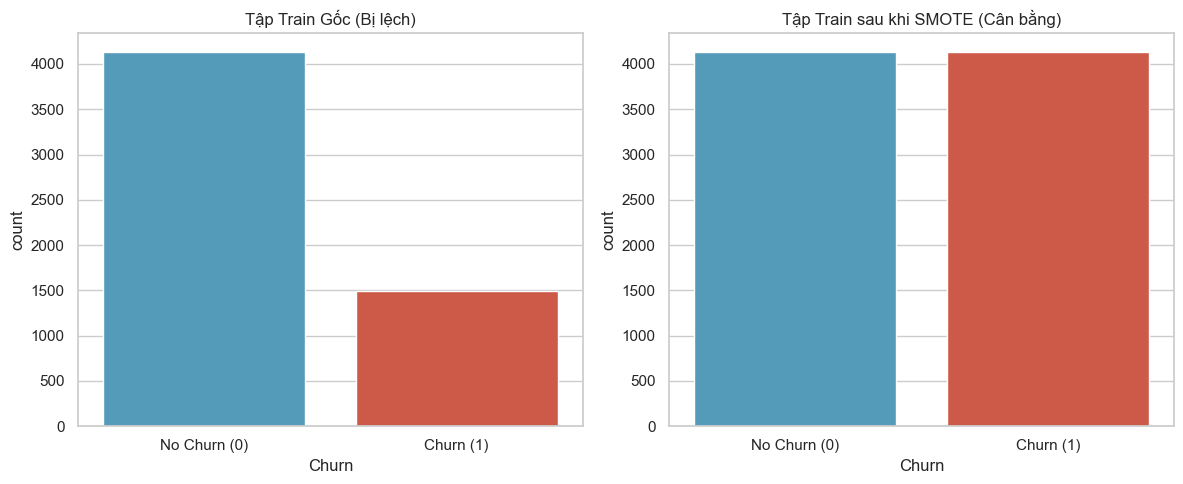

In [6]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. TÁCH DỮ LIỆU ĐẦU VÀO (X) VÀ BIẾN MỤC TIÊU (y)
target_col = 'Churn'
X = df.drop(target_col, axis=1) # Bỏ cột Churn ra để làm dữ liệu đầu vào
y = df[target_col]              # Cột Churn là mục tiêu cần dự đoán

# 2. TÁCH TẬP TRAIN (80%) VÀ TEST (20%)
# Tham số stratify=y đảm bảo tỷ lệ Churn trong tập Train và Test được giữ nguyên như tập dữ liệu gốc
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Kích thước X_train ban đầu: {X_train.shape}")
print(f"Tỷ lệ nhãn y_train ban đầu:\n{y_train.value_counts()}")

# 3. KHỞI TẠO VÀ ÁP DỤNG SMOTE (CHỈ TRÊN TẬP TRAIN)
smote = SMOTE(random_state=42)

# Fit và Transform đồng thời trên X_train và y_train
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\n--- KẾT QUẢ SAU KHI DÙNG SMOTE ---")
print(f"Kích thước X_train mới: {X_train_smote.shape}")
print(f"Tỷ lệ nhãn y_train mới (Đã cân bằng 50/50):\n{y_train_smote.value_counts()}")

# 4. TRỰC QUAN HÓA SỰ THAY ĐỔI
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Biểu đồ tập Train gốc
sns.countplot(x=y_train, ax=axes[0], palette=['#43a2ca', '#e34a33'])
axes[0].set_title('Tập Train Gốc (Bị lệch)')
axes[0].set_xticklabels(['No Churn (0)', 'Churn (1)'])

# Biểu đồ tập Train sau khi SMOTE
sns.countplot(x=y_train_smote, ax=axes[1], palette=['#43a2ca', '#e34a33'])
axes[1].set_title('Tập Train sau khi SMOTE (Cân bằng)')
axes[1].set_xticklabels(['No Churn (0)', 'Churn (1)'])

plt.tight_layout()
plt.show()

Đang huấn luyện Random Forest...
Đang huấn luyện XGBoost...


C:\Users\Home\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [11:59:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



KẾT QUẢ ĐÁNH GIÁ: Random Forest
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.71      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407

Accuracy (Độ chính xác tổng): 0.7761
Recall (Tỷ lệ bắt trúng người rời bỏ): 0.6043 <--- CHỈ SỐ QUAN TRỌNG NHẤT
F1-Score (Sự cân bằng giữa Precision và Recall): 0.5893


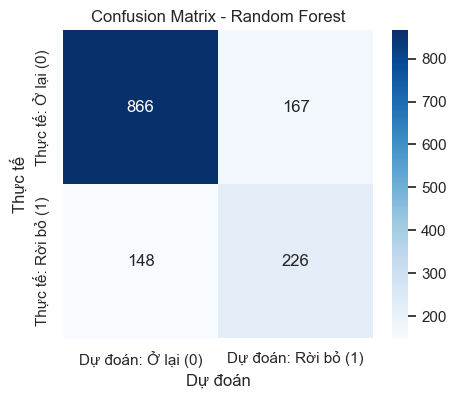


KẾT QUẢ ĐÁNH GIÁ: XGBoost
              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1033
           1       0.55      0.61      0.58       374

    accuracy                           0.77      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.77      0.77      0.77      1407

Accuracy (Độ chính xác tổng): 0.7655
Recall (Tỷ lệ bắt trúng người rời bỏ): 0.6150 <--- CHỈ SỐ QUAN TRỌNG NHẤT
F1-Score (Sự cân bằng giữa Precision và Recall): 0.5823


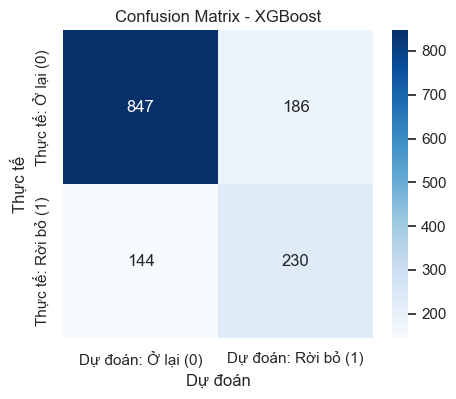

In [7]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. KHỞI TẠO MÔ HÌNH ---
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# XGBoost
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')

# --- 2. HUẤN LUYỆN (TRAIN) MÔ HÌNH ---
# Lưu ý: Chúng ta fit mô hình trên tập dữ liệu đã được SMOTE cân bằng (X_train_smote)
print("Đang huấn luyện Random Forest...")
rf_model.fit(X_train_smote, y_train_smote)

print("Đang huấn luyện XGBoost...")
xgb_model.fit(X_train_smote, y_train_smote)

# --- 3. DỰ ĐOÁN TRÊN TẬP TEST ---
# Lưu ý: Tập Test (X_test) KHÔNG được áp dụng SMOTE, nó giữ nguyên tính chất mất cân bằng thực tế
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

# --- 4. HÀM ĐÁNH GIÁ CHUNG ---
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n{'='*40}")
    print(f"KẾT QUẢ ĐÁNH GIÁ: {model_name}")
    print(f"{'='*40}")
    
    # In ra báo cáo chi tiết
    print(classification_report(y_true, y_pred))
    
    # Tính toán các chỉ số kinh doanh quan trọng
    acc = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred) # Quan trọng nhất bài toán Churn
    f1 = f1_score(y_true, y_pred)
    
    print(f"Accuracy (Độ chính xác tổng): {acc:.4f}")
    print(f"Recall (Tỷ lệ bắt trúng người rời bỏ): {recall:.4f} <--- CHỈ SỐ QUAN TRỌNG NHẤT")
    print(f"F1-Score (Sự cân bằng giữa Precision và Recall): {f1:.4f}")
    
    # Vẽ Ma trận nhầm lẫn (Confusion Matrix)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Dự đoán: Ở lại (0)', 'Dự đoán: Rời bỏ (1)'],
                yticklabels=['Thực tế: Ở lại (0)', 'Thực tế: Rời bỏ (1)'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Thực tế')
    plt.xlabel('Dự đoán')
    plt.show()

# Gọi hàm đánh giá cho cả 2 mô hình
evaluate_model(y_test, rf_preds, "Random Forest")
evaluate_model(y_test, xgb_preds, "XGBoost")

Trong bài toán kinh doanh, việc đoán nhầm một người 'Ở lại' thành 'Rời bỏ' (False Positive) chỉ làm tốn một chút chi phí voucher khuyến mãi. Nhưng nếu đoán nhầm một người 'Rời bỏ' thành 'Ở lại' (False Negative) – tức là mô hình bỏ lót khách hàng – công ty sẽ mất hẳn doanh thu từ người đó. Do vậy, em ưu tiên tối ưu hóa chỉ số Recall để mô hình 'thà bắt nhầm còn hơn bỏ sót' những khách hàng có rủi ro rời đi cao.

--- TOP 5 YẾU TỐ QUAN TRỌNG NHẤT ---


,Feature,Importance
25,Contract_Two year,0.337620
24,Contract_One year,0.220884
11,InternetService_No,0.134524
8,MultipleLines_No phone service,0.037154
13,OnlineSecurity_Yes,0.027726


C:\Users\Home\AppData\Local\Temp\ipykernel_12420\2716473921.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_5_features, x='Importance', y='Feature', palette='magma')


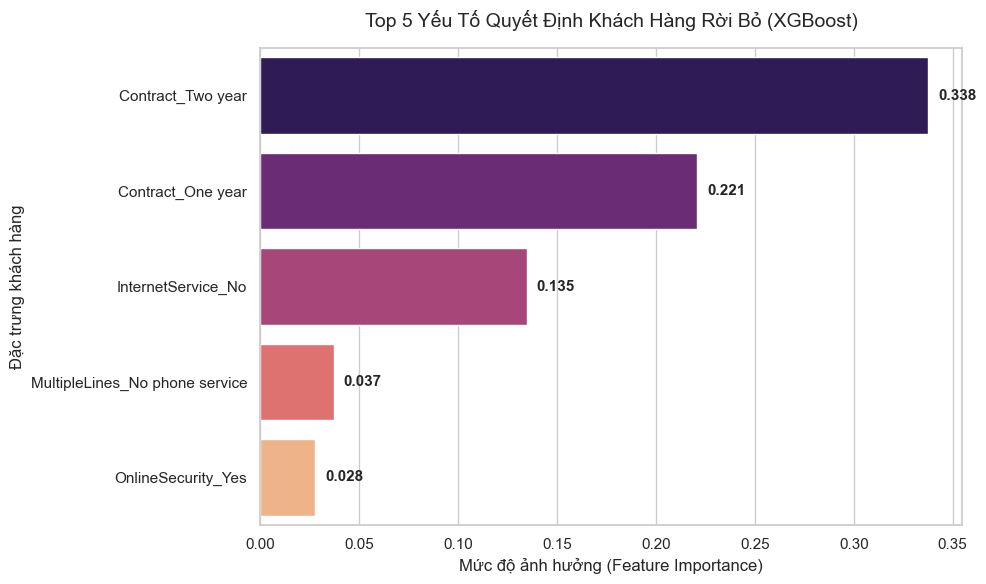

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Lấy mảng giá trị Feature Importance từ mô hình XGBoost
importances = xgb_model.feature_importances_

# 2. Ghép nối giá trị này với tên các cột dữ liệu gốc (X.columns)
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# 3. Sắp xếp giảm dần và chỉ lấy 5 yếu tố đứng đầu
top_5_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(5)

print("--- TOP 5 YẾU TỐ QUAN TRỌNG NHẤT ---")
display(top_5_features)

# 4. Vẽ biểu đồ thanh ngang (Horizontal Bar Chart)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_5_features, x='Importance', y='Feature', palette='magma')

plt.title('Top 5 Yếu Tố Quyết Định Khách Hàng Rời Bỏ (XGBoost)', fontsize=14, pad=15)
plt.xlabel('Mức độ ảnh hưởng (Feature Importance)', fontsize=12)
plt.ylabel('Đặc trưng khách hàng', fontsize=12)

# Thêm giá trị số lên từng thanh biểu đồ cho chuyên nghiệp
for index, value in enumerate(top_5_features['Importance']):
    plt.text(value + 0.005, index, f'{value:.3f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [9]:
import joblib
import os

# Tạo thư mục src/ nếu chưa có
os.makedirs('../src', exist_ok=True)

# LƯU MÔ HÌNH XGBOOST
joblib.dump(xgb_model, '../src/xgboost_churn_model.pkl')

# BẮT BUỘC LƯU: Cấu trúc cột của tập Train
# Lấy tên cột từ X_train_smote hoặc X_train
joblib.dump(X_train_smote.columns.tolist(), '../src/model_columns.pkl')

print("✅ Đã xuất mô hình và danh sách cột thành công vào thư mục src/")

✅ Đã xuất mô hình và danh sách cột thành công vào thư mục src/
